<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões principais

### Problema 3

A figura mostra uma viga fabricada com um perfil tubular, com dimensões transversais 50 $\times$ 100 mm $²$ e com 6 mm de espessura, à qual foi soldada a barra AB. No ponto A estão aplicadas três forças de 80 kN, 20 kN e 30 kN, respetivamente na direção dos eixos $x$, $y$ e $z$, como se indica.

**a)** Determine a distribuição de tensões normais na secção que contém os pontos a, b, e c, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

**b)** Obtenha o tensor das tensões nos pontos a, b, e c, referido ao sistema de eixos indicado.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P3.png"
width="500">

#### Info gráfico

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P3_iGraphic.png"
width="700">

### Resolução

### Método de Análise

Embora existam várias formas de analisar uma estrutura submetida a cargas combinadas, o procedimento geralmente inclui os seguintes passos:

1. Selecionar um ponto na estrutura onde as tensões devem ser determinadas. Geralmente, o ponto é escolhido numa secção transversal onde as tensões são elevadas, como ocorre, por exemplo, numa secção transversal onde o momento fletor atinge seu valor máximo.

2. Para cada carga na estrutura, determinar os esforços internos na secção transversal que contém o ponto selecionado. Esses esforços podem incluir o esforço axial ($N$), os esforços transversos ($V_y, V_z$), os momentos fletores ($M_y, M_z$) e o momento de torção ($M_x \equiv T$), em relação ao referencial cartesiano principal de inércia da secção, com origem no centroide da área de secção.

3. Calcular as tensões normais e de corte no ponto selecionado devido a cada um dos esforços internos resultantes. As tensões são diretamente determinadas a partir das fórmulas de tensão derivadas para a flexão e torção de elementos elásticos: $σ = \frac{P}{A}$, $\tau = \frac{T}{2A_0t}$, $σ = \frac{My}{I}$, $τ = \frac{VQ}{Ib}$.

4. Combinar as componentes de tensão para obter a matriz do tensor de tensões no ponto selecionado, levando em consideração os sentidos positivos para essas componentes em relação aos eixos do sistema de coordenadas.

5. Determinar as tensões principais e as tensões máximas de corte no ponto selecionado usando as equações de transformação do tensor de tensões. Finalmente, poder-se-ia também determinar as deformações no ponto, recorrendo às leis constitutivas do material.

### Sistema força-binário equivalente

- Membro ABDE submetido a um sistema de forças.
- Diagrama de corpo livre do segmento ABC, usado para determinar as forças internas e momentos na secção transversal C.
- Forças e momentos internos separados em: (a) as forças e momentos que geram tensões normais e (b) forças e momentos que tão origem a tensões de corte.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/FBequivalente.png"
width="600">



### Resolução

#### **a)** Determine a distribuição de tensões normais na secção que contém os pontos a, b, e c, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

In [215]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.tub_b = 50.*1e-3  # unit: m
d.tub_h = 100.*1e-3 # unit: m
d.tub_e = 6.*1e-3 # unit: m
d.xL = 150.e-3 # unit: m
d.zac = 80.e-3 # unit: m
d.zc = 25.e-3 # unit: m
d.yab = 50.e-3 # unit: m
d.Px = 80.*1e3 # unit: N/m
d.Py = 20.*1e3 # unit: N/m
d.Pz = 30.*1e3 # unit: N/m

#### Análise dos esforços internos na secção contendo os pontos a, b e c

**Sistema força-binário equivalente** 

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P31.png"
width="500">

- Esforço axial, $N$:

\begin{equation*}
N = P_x
\end{equation*}

In [216]:
N = d.Px
print(f'N = {N:.1f} [N]')

N = 80000.0 [N]


- Esforço tranverso, $V_y$:

\begin{equation*}
V_y = P_y
\end{equation*}

In [217]:
Vy = d.Py
print(f'Vy = {Vy:.1f} [N]')

Vy = 20000.0 [N]


- Esforço tranverso, $V_z$

\begin{equation*}
V_z = P_z
\end{equation*}

In [218]:
Vz = d.Pz
print(f'Vz = {Vz:.1f} [N]')

Vz = 30000.0 [N]


- Momento de torção $(M_x\equiv T)$

Apenas as forças ortogonais ao eixo $x$ exercem momento torsor,

\begin{equation*}
T = -z_{AC} \cdot P_y  + P_z\cdot h/2
\end{equation*}

In [219]:
T = -(d.zac+d.tub_b/2)*d.Py + d.tub_h/2*d.Pz
print(f'T = -({d.zac+d.tub_b/2:.3f}){d.Py} + ({d.tub_h/2:.3f}){d.Pz:.1f} = {T:.1f} [N.m]')

T = -(0.105)20000.0 + (0.050)30000.0 = -600.0 [N.m]


- Momento de flexão, $M_{y}$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular,

\begin{equation*}
M_y = z_{AC} \cdot P_x - x_L \cdot P_z
\end{equation*}

In [220]:
My = (d.zac+d.tub_b/2)*d.Px - d.xL*d.Pz
print(f'My = ({d.zac+d.tub_b/2:.3f}){d.Px:.1f} - ({d.xL:.3f}){d.Pz:.1f} = {My:.1f} [N.m]')

My = (0.105)80000.0 - (0.150)30000.0 = 3900.0 [N.m]


- Momento de flexão, $M_{z}$

As forças de exercem momento em relação ao eixo $z$ são as forças contidas no plano $x-y$, $P_x$, $P_y$:

\begin{equation*}
M_z = - x_{AC} P_x \cdot h/2 + P_y x_L
\end{equation*}

In [221]:
Mz = -d.tub_h/2*d.Px + d.xL*d.Py
print(f'Mz = -({d.tub_h/2:.3f}){d.Px:.1f} + ({d.xL:.3f}){d.Py:.1f} = {Mz:.1f} [N.m]')

Mz = -(0.050)80000.0 + (0.150)20000.0 = -1000.0 [N.m]


De forma equivalente, pelo desenvolvimento do produto vetorial, considerando o momento da força resultante em relação ao centroide da secção (contendo os pontos a, b e c):

\begin{equation*}
\begin{vmatrix}
\vec{\imath} & \vec{\jmath} & \vec{k} \\
x & y & z \\
P_x & P_y & P_z \\
\end{vmatrix}
~\wedge~
\vec{r} = 0.150~\vec{\imath} + 0.050~\vec{\jmath} +
0.105~\vec{k}~\textrm{[m]}
~\wedge~
\vec{P} = 80~\vec{\imath} + 20~\vec{\jmath} +
30~\vec{k}~\textrm{[kN]}
\end{equation*}

In [222]:
import sympy as sy
from sympy.solvers import solve
from sympy.physics.mechanics import ReferenceFrame, Vector, dot, cross

S = ReferenceFrame('S') # ||x|
vRC = d.xL*S.x + d.tub_h/2*S.y + (d.zac+d.tub_b/2)*S.z
print(f'vRC : {vRC}')
vFR = d.Px*S.x + d.Py*S.y + d.Pz*S.z
print(f'vFR : {vFR}')
Cross1 = cross(vRC,vFR)
print('Cross 1: ',Cross1)
print(f'Mx : {Cross1.args[0][0].args[2][0]:.1f} [N.m]')
print(f'My : {Cross1.args[0][0].args[2][1]:.1f} [N.m]')
print(f'Mz : {Cross1.args[0][0].args[2][2]:.1f} [N.m]')

vRC : 0.15*S.x + 0.05*S.y + 0.105*S.z
vFR : 80000.0*S.x + 20000.0*S.y + 30000.0*S.z
Cross 1:  - 600.0*S.x + 3900.0*S.y - 1000.0*S.z
Mx : -600.0 [N.m]
My : 3900.0 [N.m]
Mz : -1000.0 [N.m]


##### Propriedades de secção

- Área da secção

In [223]:
A = d.tub_b*d.tub_h - (d.tub_b-2*d.tub_e)*(d.tub_h-2*d.tub_e)
print(f'A = {d.tub_b:.3f}x{d.tub_h:.3f} - {d.tub_b-2*d.tub_e:.3f}x{d.tub_h-2*d.tub_e:.3f} = {A:.3e} [m^2]')

A = 0.050x0.100 - 0.038x0.088 = 1.656e-03 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [224]:
def irect(b,h): return b*h**3/12

Iz1 = irect(d.tub_b,d.tub_h)
Iz2 = irect(d.tub_b-2*d.tub_e,d.tub_h-2*d.tub_e)
Iz = Iz1 - Iz2
print(f'Iz = {Iz1:.3e} - {Iz2:.3e} = {Iz:.3e} [m^4]')

Iz = 4.167e-06 - 2.158e-06 = 2.009e-06 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [225]:
Iy1 = irect(d.tub_h,d.tub_b)
Iy2 = irect(d.tub_h-2*d.tub_e,d.tub_b-2*d.tub_e)
Iy = Iy1 - Iy2
print(f'Iy = {Iy1:.3e} - {Iy2:.3e} = {Iy:.3e} [m^4]')

Iy = 1.042e-06 - 4.024e-07 = 6.393e-07 [m^4]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeito de concentração de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx} = \frac{N}{A} + \frac{|M_z|}{I_z}y + \frac{|M_y|}{I_y} z
\end{equation*}

De notar que o momento fletor $M_z$ é negativo, contudo o momento fletor $M_y$ é positivo.


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P32.png"
width="700">



In [226]:
y, z, sigx = sy.symbols('y z sigx')

eqsigx = N/A + np.abs(Mz)/Iz*y + np.abs(My)/Iy*z
Eq = sigx - eqsigx
print(f'Eq = {Eq}')
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {sigxx*1e-6} [MPa]')

Eq = sigx - 497841359.863631*y - 6100689534.34532*z - 48309178.7439614
sigxx(y,z)  = 497.841359863631*y + 6100.68953434532*z + 48.3091787439614 [MPa]


In [227]:
yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

y = -12.2542842483325*z - 0.0970372946859905 (recta geométrica do eixo neutro) [m]
z = -0.0816041132827546*y - 0.00791864238820761 (recta geométrica do eixo neutro) [m]


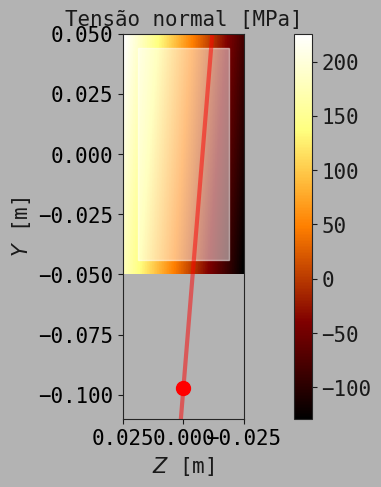

In [228]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylim([-1.1*d.tub_h,1.*d.tub_h/2])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
ax.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e), d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [229]:
ymax_, zmax_ = d.tub_h/2, d.tub_b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max :: (y = {ymax_}, z = {zmax_}) :: {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -d.tub_h/2, -d.tub_b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min :: (y = {ymin_}, z = {zmin_}) :: {sigmin_*1e-6:.2f} [MPa]')

sig.max :: (y = 0.05, z = 0.025) :: 225.72 [MPa]
sig.min :: (y = -0.05, z = -0.025) :: -129.10 [MPa]


#### **b)** Obtenha o tensor das tensões nos pontos a, b, e c, referido ao sistema de eixos indicado.

##### Tensões normais ($N, M_y, M_z$)

In [230]:
yA, zA = 0, -d.tub_b/2
sigA = tensnormal(yA, zA)
print(f'sig.A :: ({yA:.3f},{zA:.3f}) :: {sigA*1e-6:.2f} [MPa]')

yB, zB = d.tub_h/2-d.tub_e, -d.tub_b/2
sigB = tensnormal(yB, zB)
print(f'sig.B :: ({yB:.3f},{zB:.3f}) :: {sigB*1e-6:.2f} [MPa]')

yC, zC = d.tub_h/2, d.tub_b/2-d.zc
sigC = tensnormal(yC, zC)
print(f'sig.C :: ({yC:.3f},{zC:.3f}) :: {sigC*1e-6:.2f} [MPa]')

sig.A :: (0.000,-0.025) :: -104.21 [MPa]
sig.B :: (0.044,-0.025) :: -82.30 [MPa]
sig.C :: (0.050,0.000) :: 73.20 [MPa]


##### Tensões tangenciais devidas ao momento torsor $T$

A força vertical $P_y$ irá gerar um momento torsor na viga ao longo do eixo $x$. Usa-se aqui a regra da mão direita e a convenção de sinal: momento torsor positivo a apontar para fora do veio. A expressão geral da relação da tensão de corte e momento torsor é dada por:

\begin{equation*}
\tau = \frac{|T|}{2A_0t}
\end{equation*}

onde
- $|T|$ : é o módulo do momento torsor;
- $A_0$ : é a área interna definida pelo contorno da linha central da parede do perfil;
- $t$ : é a espessura da parede do perfil tubular.

Na fórmula do momento torsor, o momento é considerado positivo. A torsão gerada pela força $P_y$ irá gerar tensões de corte como representadas na figura:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P33.png"
width="700">

In [231]:
tor_A0 = (d.tub_h-d.tub_e)*(d.tub_b-d.tub_e)
print(f'tor_A0 = {d.tub_h-d.tub_e:.3f}x{d.tub_b-d.tub_e:.3f} = {tor_A0:.3e} [m²]')
tor_t = d.tub_e
print(f'tor_t = {tor_t:.3f} [m]')
tau_T = np.abs(T)/2/tor_A0/tor_t
print(f'tau_T = {tau_T*1e-6:.3f} [MPa]')

tor_A0 = 0.094x0.044 = 4.136e-03 [m²]
tor_t = 0.006 [m]
tau_T = 12.089 [MPa]


- Pontos a, b e c:

A tensão de corte em cada ponto de interesse ao longo do perfil de parede fina é:

\begin{equation*}
\tau_{xy}^a = -\frac{T}{2A_0t}
\quad\wedge\quad
\tau_{xy}^b = -\frac{T}{2A_0t}
\quad\wedge\quad
\tau_{xz}^c = -\frac{T}{2A_0t}
\end{equation*}

In [232]:
tau_T_a = -tau_T
print(f'tau_T_a = {tau_T_a*1e-6:.3f} [MPa]')

tau_T_b = -tau_T
print(f'tau_T_b = {tau_T_b*1e-6:.3f} [MPa]')

tau_T_c = -tau_T
print(f'tau_T_c = {tau_T_c*1e-6:.3f} [MPa]')

tau_T_a = -12.089 [MPa]
tau_T_b = -12.089 [MPa]
tau_T_c = -12.089 [MPa]


##### Tensões tangenciais devidas ao esforço transverso $V_y$

Recorrendo ao formulário da expressão da tensão de corte em relação ao esforço transverso (de notar que nesta expressão o valor de $V$ é considerado positivo de acordo com o sistema de coordenadas escolhido):

\begin{equation*}
\tau = \left| \frac{V_yQ_z}{I_zt} \right|
\quad\wedge\quad Q_z = \int_A^* y\,\mathrm{d}x = A^*\overline{y} = \sum_i A_i^*\overline{y}_i
\end{equation*}

De notar que a força vertical $P_y$ gera um fluxo de corte como o representado na figura:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P34.png"
width="700">

- Ponto a:

\begin{equation*}
\tau_{xy}^a(V_y) = \left| \frac{V_yQ_z^a}{I_zt^a} \right|
\quad\wedge\quad Q_z^a = A_M\overline{y}_M - A_m\overline{y}_m
\quad\wedge\quad t^a = 2 e
\end{equation*}

Para determinar a tensão de corte no ponto a, o primeiro momento de área, $Q_z^a$, deve ser calculado cortando a área como ilustrado na figura:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P35.png"
width="700">

In [233]:
Az_a1 = d.tub_b*d.tub_h/2
print(f'Az1 = {d.tub_b:.3f}x{d.tub_h/2:.3f} = {Az_a1:.3e} [m²]')
z_a1 = d.tub_h/2/2
print(f'z1 = {z_a1:.3e} [m]')
Qz_a1 = Az_a1*z_a1
print(f'Qz_a1 = {Qz_a1:.3e} [m³]')
Az_a2 = (d.tub_b-2*d.tub_e)*(d.tub_h/2-d.tub_e)
print(f'Az2 = {d.tub_b-2*d.tub_e:.3f}x{d.tub_h/2-d.tub_e:.3f} = {Az_a2:.3e} [m²]')
z_a2 = (d.tub_h/2 - d.tub_e)/2
print(f'z2 = {z_a2:.3e} [m]')
Qz_a2 = Az_a2*z_a2
print(f'Qz2 = {Qz_a2:.3e} [m³]')
Qz_a = Qz_a1 - Qz_a2
print(f'Qz_a = {Qz_a:.3e} [m³]')
tauxy_Vy_a = np.abs(Vy)*Qz_a/Iz/2/d.tub_e
print(f'::\nVy = {Vy:.1f} [N]')
print(f'Qz = {Qz_a:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vy):.1f} :: tauxy_Vy_a  = {tauxy_Vy_a*1e-6:.3f} [MPa]')

Az1 = 0.050x0.050 = 2.500e-03 [m²]
z1 = 2.500e-02 [m]
Qz_a1 = 6.250e-05 [m³]
Az2 = 0.038x0.044 = 1.672e-03 [m²]
z2 = 2.200e-02 [m]
Qz2 = 3.678e-05 [m³]
Qz_a = 2.572e-05 [m³]
::
Vy = 20000.0 [N]
Qz = 2.572e-05 [m³]
Iz = 2.009e-06 [m⁴]
t  = 1.200e-02 [m]
>>> Vy = 20000.0 :: tauxy_Vy_a  = 21.337 [MPa]


- Ponto b:

\begin{equation*}
\tau_{xy}^b(V_y) = \left| \frac{V_yQ_z^b}{I_zt^b} \right|
\quad\wedge\quad Q_z^b = A^\star\overline{y}^\star
\quad\wedge\quad t^b = 2 e
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P36.png"
width="700">

In [234]:
print('area a vermelho:')
A_b = d.tub_b*d.tub_e
print(f'A_b = {d.tub_b:.3f}x{d.tub_e:.3f} = {A_b:.3e} [m²]')
y_b = d.tub_h/2-d.tub_e/2
print(f'z_b = {y_b:.3e} [m]')
Qz_b = A_b*y_b
print(f'Qz_b = {Qz_b:.3e} [m³]')

tauxy_Vy_b = np.abs(Vy*Qz_b)/Iz/2/d.tub_e
print(f'::\nVy = {Vy:.1f} [N]')
print(f'Qz = {Qz_b:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vy):.1f} :: tauxy_Vy_b  = {tauxy_Vy_b*1e-6:.3f} [MPa]')

area a vermelho:
A_b = 0.050x0.006 = 3.000e-04 [m²]
z_b = 4.700e-02 [m]
Qz_b = 1.410e-05 [m³]
::
Vy = 20000.0 [N]
Qz = 1.410e-05 [m³]
Iz = 2.009e-06 [m⁴]
t  = 1.200e-02 [m]
>>> Vy = 20000.0 :: tauxy_Vy_b  = 11.699 [MPa]


- Ponto b (em alternativa):

\begin{equation*}
\tau_{xy}^b(V_y) = \left| \frac{V_yQ_z^b}{I_zt^b} \right|
\quad\wedge\quad Q_z^b = A^\star\overline{y}^\star
\quad\wedge\quad t^b = e
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P36_b.png"
width="700">

In [244]:
print('area definida desde o ponto de entrada inferior (Qz=0) até b:')
A1_ = d.tub_b/2*d.tub_e
y1_ = d.tub_h/2-d.tub_e/2
Qz_b_v2 = A1_*y1_
print(f'A_b_v2 = ({A1_:.3e})({y1_:.3f}) = {Qz_b_v2:.3e} [m²]')

tauxy_Vy_b_v2 = np.abs(Vy*Qz_b_v2)/Iz/d.tub_e
print(f'::\nVy = {Vy:.1f} [N]')
print(f'Qz = {Qz_b_v2:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vy):.1f} :: tauxy_Vy_b_v2  = {tauxy_Vy_b_v2*1e-6:.3f} [MPa]')

area definida desde o ponto de entrada inferior (Qz=0) até b:
A_b_v2 = (1.500e-04)(0.047) = 7.050e-06 [m²]
::
Vy = 20000.0 [N]
Qz = 7.050e-06 [m³]
Iz = 2.009e-06 [m⁴]
t  = 6.000e-03 [m]
>>> Vy = 20000.0 :: tauxy_Vy_b_v2  = 11.699 [MPa]


- Ponto c:

\begin{equation*}
\tau_{xz}^c(V_y) = 0
\end{equation*}

In [236]:
tauxy_Vy_c = 0
print(f'>>> tauxy_Vy_c  = {tauxy_Vy_c*1e-6:.3f} [MPa]')

>>> tauxy_Vy_c  = 0.000 [MPa]


##### Tensões tangenciais devidas ao esforço transverso $V_z$

\begin{equation*}
\tau = \left| \frac{V_zQ_y}{I_yt} \right|
\quad\wedge\quad Q_y = \int_A^* z\,\mathrm{d}A = A^*\overline{z} = \sum_i A_i^*\overline{z}_i
\end{equation*}

De notar que as quantidades envolvidas no cálculo do primeiro momento de área são conceptualmente positivas ($A_i^*,~\overline{z}_i)$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P37.png"
width="700">

- Ponto a:

\begin{equation*}
\tau_{xy}^a(V_z) = 0
\end{equation*}

In [237]:
tauxy_Vz_a = 0
print(f'>>> tauxy_Vz_a  = {tauxy_Vz_a*1e-6:.3f} [MPa]')

>>> tauxy_Vz_a  = 0.000 [MPa]


- Ponto b:

\begin{equation*}
\tau_{xy}^b (V_z) = \left| \frac{V_zQ_y^b}{I_yt^b} \right|
\quad\wedge\quad Q_y^b = A^*\overline{z}
\quad\wedge\quad t^b = 2 e
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P38.png"
width="700">

In [238]:
Ay_b = (d.tub_h-2*d.tub_e)*d.tub_e
print(f'Ay_b = {d.tub_h-2*d.tub_e:.3f}x{d.tub_e:.3f} = {Ay_b:.3e} [m²]')
z_b = d.tub_b/2-d.tub_e/2
print(f'z_b = {z_b:.3e} [m]')
Qy_b = Ay_b*z_b
print(f'Qy_b = {Qy_b:.3e} [m³]')
tauxy_Vz_b = np.abs(Vz)*Qy_b/Iy/2/d.tub_e
print(f'::\nVz = {Vz:.1f} [N]')
print(f'Qy = {Qy_b:.3e} [m³]')
print(f'Iy = {Iy:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> Vz = {np.abs(Vz):.1f} :: tauxy_Vy_a = {tauxy_Vz_b*1e-6:.3f} [MPa]')

Ay_b = 0.088x0.006 = 5.280e-04 [m²]
z_b = 2.200e-02 [m]
Qy_b = 1.162e-05 [m³]
::
Vz = 30000.0 [N]
Qy = 1.162e-05 [m³]
Iy = 6.393e-07 [m⁴]
t  = 1.200e-02 [m]
>>> Vz = 30000.0 :: tauxy_Vy_a = 45.427 [MPa]


- Ponto c:

\begin{equation*}
\tau_{xy}^c (V_z) = \left| \frac{V_zQ_y^c}{I_yt^c} \right|
\quad\wedge\quad Q_y^c = A^*\overline{z}
\quad\wedge\quad t^c = 2 e
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P3/MSII_Au07_P39.png"
width="700">

In [239]:
Ay_c1 = d.tub_b/2*d.tub_h
print(f'Az_c1 = {d.tub_b/2:.3f}x{d.tub_h:.3f} = {Ay_c1:.3e} [m²]')
z_c1 = d.tub_b/2/2
print(f'z_c1 = {z_c1:.3e} [m]')
Qy_c1 = Ay_c1*z_c1
print(f'Qy_c1 = {Qy_c1:.3e} [m³]')
Ay_c2 = (d.tub_b/2-d.tub_e)*(d.tub_h-2*d.tub_e)
print(f'Ay_c2 = {d.tub_b/2-d.tub_e:.3f}x{d.tub_h-2*d.tub_e:.3f} = {Ay_c2:.3e} [m²]')
z_c2 = (d.tub_b/2-d.tub_e)/2
print(f'z_c2 = {z_c2:.3e} [m]')
Qy_c2 = Ay_c2*z_c2
print(f'Qy_c2 = {Qy_c2:.3e} [m³]')
Qy_c = Qy_c1 - Qy_c2
print(f'Qy_c = {Qy_c:.3e} [m³]')
tauxy_Vz_c = np.abs(Vz)*Qy_c/Iy/2/d.tub_e
print(f'::\nVz = {Vz:.1f} [N]')
print(f'Qy = {Qy_c:.3e} [m³]')
print(f'Iy = {Iy:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> Vz = {np.abs(Vz):.1f} :: tauxy_Vz_c = {tauxy_Vz_c*1e-6:.3f} [MPa]')

Az_c1 = 0.025x0.100 = 2.500e-03 [m²]
z_c1 = 1.250e-02 [m]
Qy_c1 = 3.125e-05 [m³]
Ay_c2 = 0.019x0.088 = 1.672e-03 [m²]
z_c2 = 9.500e-03 [m]
Qy_c2 = 1.588e-05 [m³]
Qy_c = 1.537e-05 [m³]
::
Vz = 30000.0 [N]
Qy = 1.537e-05 [m³]
Iy = 6.393e-07 [m⁴]
t  = 1.200e-02 [m]
>>> Vz = 30000.0 :: tauxy_Vz_c = 60.092 [MPa]


- Tensor das tensões num ponto material:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

No problema de flexão em estudo apenas existem tensões normais segundo a direção $x~:~\sigma_{xx}=N/A~,~\sigma_{yy}=\sigma_{zz}=0$. Por outro lado, os pontos a,b e c estão situado num plano de corte $y-z$ com normal o eixo $x$ pelo que: $\tau_{yz} = 0$, resultando:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

- Tensor das tensões no ponto a, $[\sigma_a]$:

\begin{equation*}
\sigma_{xx}(y_a,z_a)
~\wedge~ \tau_{xy} = -\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

em resumo,

\begin{equation*}
[\sigma_a] =
\begin{bmatrix}
\sigma_{xx}(y_a,z_a) & \left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt}\right)  & 0 \\
\left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt}\right)  & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [240]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]], np.float64)

tta = tenstens(sigA,tau_T_a+tauxy_Vy_a,0,0,0,0)
print(f"tta :: \n {np.array2string(tta*1e-6, precision=2, floatmode='fixed')} [MPa]")

tta :: 
 [[-104.21    9.25    0.00]
 [   9.25    0.00    0.00]
 [   0.00    0.00    0.00]] [MPa]


- Tensor das tensões no ponto a, $[\sigma_b]$:

\begin{equation*}
\sigma_{xx}(y_b,z_b)
~\wedge~ \tau_{xy} = -\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

em resumo,

\begin{equation*}
[\sigma_b] =
\begin{bmatrix}
\sigma_{xx}(y_b,z_b) & \left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}\right)  & 0 \\
\left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}\right)  & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [241]:
np.set_printoptions(precision=4)

ttb = tenstens(sigB,tau_T_b+tauxy_Vy_b++tauxy_Vz_b,0,0,0,0)
print(f"ttb :: \n {np.array2string(ttb*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttb :: 
 [[-82.30  45.04   0.00]
 [ 45.04   0.00   0.00]
 [  0.00   0.00   0.00]] [MPa]


- Tensor das tensões no ponto c, $[\sigma_c]$:

\begin{equation*}
\sigma_{xx}(y_c,z_c)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{xz} = -\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}
\end{equation*}

em resumo,

\begin{equation*}
[\sigma_b] =
\begin{bmatrix}
\sigma_{xx}(y_b,z_b) & 0 & \left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}\right) \\
0 & 0 & 0 \\
\left(\displaystyle-\frac{T}{2A_0t} + \frac{V_yQ_z}{I_zt} + \frac{V_zQ_y}{I_yt}\right) & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [242]:
np.set_printoptions(precision=4)

ttc = tenstens(sigC,0,tau_T_c+tauxy_Vy_c++tauxy_Vz_c,0,0,0)
print(f"ttb :: \n {np.array2string(ttc*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttb :: 
 [[73.20  0.00 48.00]
 [ 0.00  0.00  0.00]
 [48.00  0.00  0.00]] [MPa]


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>